In [ ]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[0]
sys.path.append(str(project_root))
sys.path.append(str(project_root / "src"))

import torch

from src.decoder import VAE_Decoder
from src.encoder import VAE_Encoder

from utils.utils import sample_from_vae, interpolate_between_images, interpolate_to_gif
from utils.dataset import EmojiDataset
from torch.utils.data import DataLoader

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
encoder = VAE_Encoder().to(device)
decoder = VAE_Decoder().to(device)

checkpoint = torch.load(project_root / 'checkpoints/vae/vae_epoch_0035.pth', map_location=device, weights_only=False)
encoder.load_state_dict(checkpoint['encoder'])
decoder.load_state_dict(checkpoint['decoder'])

encoder.eval();
decoder.eval();

In [4]:
tokenizer = None
dataset = EmojiDataset(project_root / 'data/emoji_dataset_128x128/emoji_dataset.json', image_size=128, tokenize=False)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

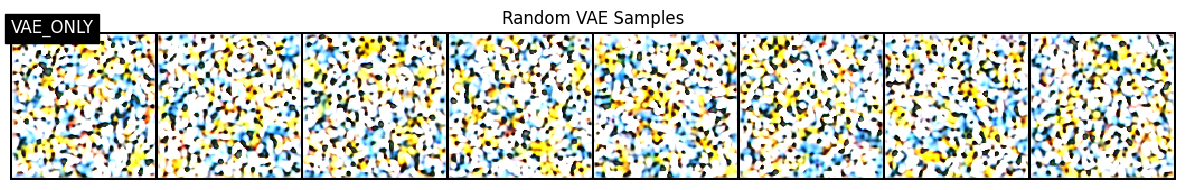

In [5]:
sample_from_vae(decoder, device)

In [9]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

def show_image(tensor_img, title=None):
    tensor_img = (tensor_img.clamp(-1, 1) + 1) / 2
    img = TF.to_pil_image(tensor_img.squeeze(0).cpu())

    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

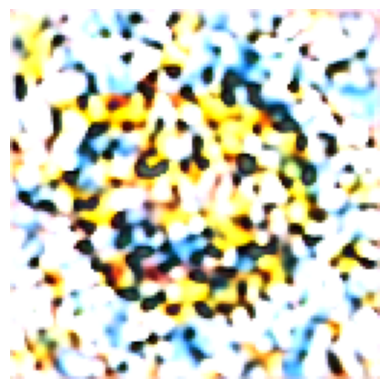

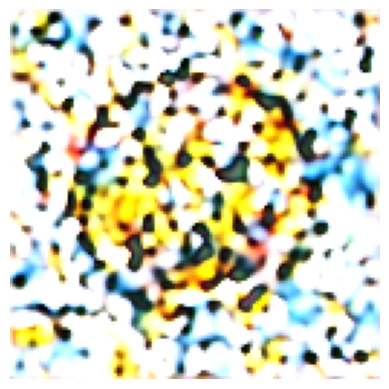

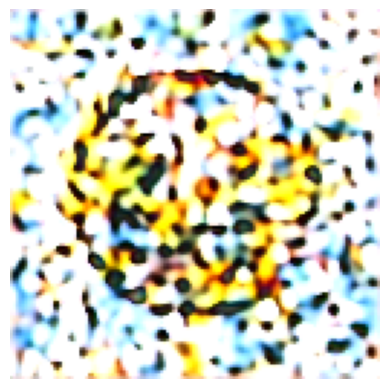

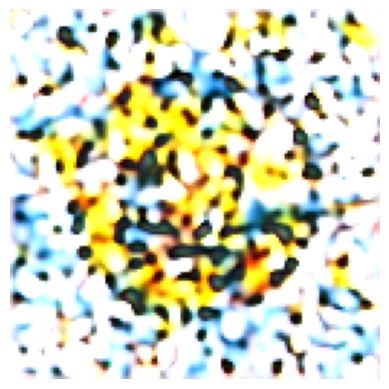

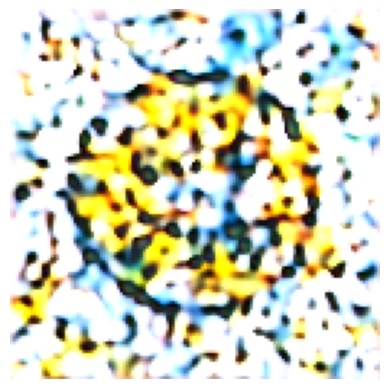

In [12]:
img = dataset[0]['image'].unsqueeze(0).to(device)
noise = torch.randn(1, 4, 32, 32).to(device)
z = encoder(img, noise)

# Slightly perturb the latent
for i in range(5):
    z_perturbed = z + torch.randn_like(z)
    img_out = decoder(z_perturbed)
    show_image(img_out)


In [6]:
IMG1_ID = 1
IMG2_ID = 627

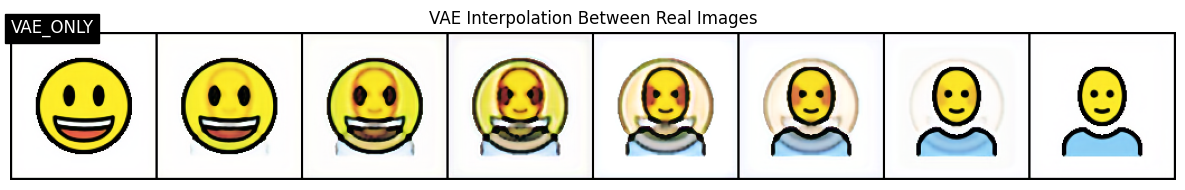

In [7]:
interpolate_between_images(encoder, decoder, dataset, IMG1_ID, IMG2_ID, device)

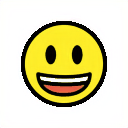

In [8]:
interpolate_to_gif(encoder, decoder, dataset, IMG1_ID, IMG2_ID, device, steps=32)

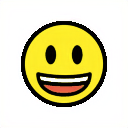

In [10]:
interpolate_to_gif(encoder, decoder, dataset, IMG1_ID, IMG2_ID - 300, device, steps=32)

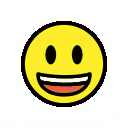

In [12]:
interpolate_to_gif(encoder, decoder, dataset, IMG1_ID, IMG2_ID - 530, device, steps=32)